<a href="https://colab.research.google.com/github/Kashishkewat/python_practice/blob/main/day40_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Random Forest (Ensemble of Decision Trees)**

#**How Random Forest works (clear flow)**


1️⃣ Bootstrap sampling (same as bagging)

Create many datasets from original data using sampling with replacement.

2️⃣ Random feature selection (the special part ⭐)

When a tree splits a node:

It does NOT look at all features

It randomly selects a subset of features

Chooses best split only from that subset

This makes trees less similar → better ensemble.

3️⃣ Train many decision trees

Each tree learns differently because:

Different data

Different features

4️⃣ Combine predictions

Regression → average of outputs

Classification → majority vote

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification


In [2]:
X,y=make_classification(n_features=5,n_redundant=0,n_informative=5,n_clusters_per_class=1)

In [3]:
df=pd.DataFrame(X,columns=["col1","col2","col3","col4","col5"])
df["target"]=y
df.shape

(100, 6)

In [4]:
df.head()

,col1,col2,col3,col4,col5,target
0,-1.446423,1.036842,-1.296062,0.948954,-1.537184,1
1,1.290615,2.022841,-3.105415,-2.491889,-2.379426,0
2,-0.614230,0.524625,-1.190731,0.110703,-0.070062,1
3,-1.774487,0.443148,1.254518,-3.035050,-1.467568,0
4,-2.807623,0.594748,-0.184128,4.025850,-3.134763,1


In [5]:
# function for row sampling
def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [8]:
df1=sample_rows(df,0.1)
#

In [9]:
df2=sample_rows(df,0.1)

In [10]:
df3=sample_rows(df,0.1)

In [11]:
df1.shape

(10, 6)

In [12]:
df2.shape

(10, 6)

In [13]:
df3.shape

(10, 6)

In [14]:
from sklearn.tree import DecisionTreeClassifier
clf1=DecisionTreeClassifier()
clf2=DecisionTreeClassifier()
clf3=DecisionTreeClassifier()

In [21]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

DecisionTreeClassifier()

[Text(0.6, 0.8333333333333334, 'x[2] <= -0.693\ngini = 0.42\nsamples = 10\nvalue = [7, 3]'),
 Text(0.4, 0.5, 'x[2] <= -2.501\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.7, 0.6666666666666667, '  False')]

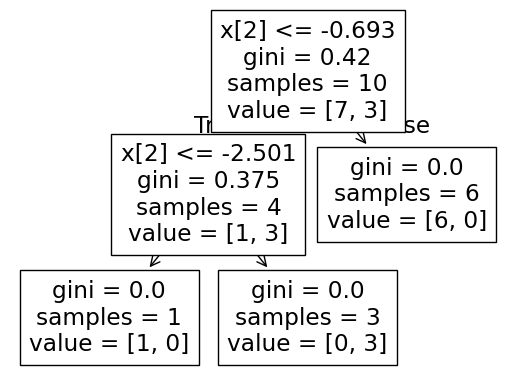

In [22]:
from sklearn.tree import plot_tree
plot_tree(clf1)

[Text(0.5, 0.75, 'x[2] <= -1.189\ngini = 0.32\nsamples = 10\nvalue = [8, 2]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.625, 0.5, '  False')]

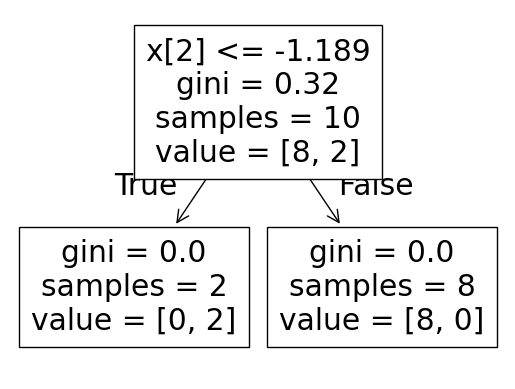

In [23]:
plot_tree(clf2)

[Text(0.4, 0.8333333333333334, 'x[3] <= -0.024\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[1] <= -0.789\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]')]

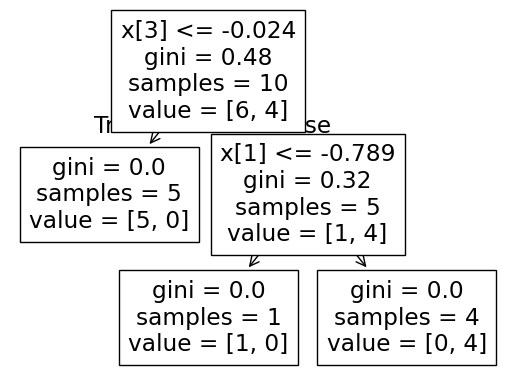

In [24]:
plot_tree(clf3)

In [25]:
clf1.predict(np.array([-0.106423,	-2.351213,	-1.741114	,0.151400	,1.560502]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [26]:
clf2.predict(np.array([-0.106423,	-2.351213,	-1.741114	,0.151400	,1.560502]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [27]:
clf3.predict(np.array([-0.106423,	-2.351213,	-1.741114	,0.151400	,1.560502]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [39]:
#function for feature sampling
def sample_features(df,percent):
  cols=random.sample(df.columns.tolist()[:-1],int(percent*df.shape[1]))
  new_df=df[cols]
  new_df["target"]=df["target"]
  return new_df


In [70]:
#using function of sample-features
import random
sample_features(df,0.8)

/tmp/ipython-input-1436777600.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df["target"]=df["target"]


,col5,col4,col2,col1,target
0,-1.537184,0.948954,1.036842,-1.446423,1
1,-2.379426,-2.491889,2.022841,1.290615,0
2,-0.070062,0.110703,0.524625,-0.614230,1
3,-1.467568,-3.035050,0.443148,-1.774487,0
4,-3.134763,4.025850,0.594748,-2.807623,1
...,...,...,...,...,...
95,-1.692941,-0.441826,2.011241,-0.468847,1
96,-3.904312,-1.056385,2.466238,1.801425,0
97,0.645030,-2.059565,-0.127144,0.415524,0
98,1.016778,1.090157,0.334771,-0.641144,1


In [41]:
df1=sample_features(df,0.8)
df2=sample_features(df,0.8)
df3=sample_features(df,0.8)

/tmp/ipython-input-1436777600.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df["target"]=df["target"]
/tmp/ipython-input-1436777600.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df["target"]=df["target"]
/tmp/ipython-input-1436777600.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.

In [42]:
df3.shape

(100, 5)

In [57]:
clf1.fit(df1.iloc[:,0:3],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:3],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:3],df3.iloc[:,-1])

DecisionTreeClassifier()

[Text(0.42391304347826086, 0.9166666666666666, 'x[1] <= -0.452\ngini = 0.5\nsamples = 100\nvalue = [49, 51]'),
 Text(0.21739130434782608, 0.75, 'x[0] <= 0.66\ngini = 0.165\nsamples = 44\nvalue = [4, 40]'),
 Text(0.32065217391304346, 0.8333333333333333, 'True  '),
 Text(0.13043478260869565, 0.5833333333333334, 'x[0] <= -1.809\ngini = 0.049\nsamples = 40\nvalue = [1, 39]'),
 Text(0.08695652173913043, 0.4166666666666667, 'x[1] <= -0.782\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.043478260869565216, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.13043478260869565, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.17391304347826086, 0.4166666666666667, 'gini = 0.0\nsamples = 38\nvalue = [0, 38]'),
 Text(0.30434782608695654, 0.5833333333333334, 'x[1] <= -2.615\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.2608695652173913, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.34782608695652173, 0.4166666666666667, 'gini = 0.0\nsamples = 3

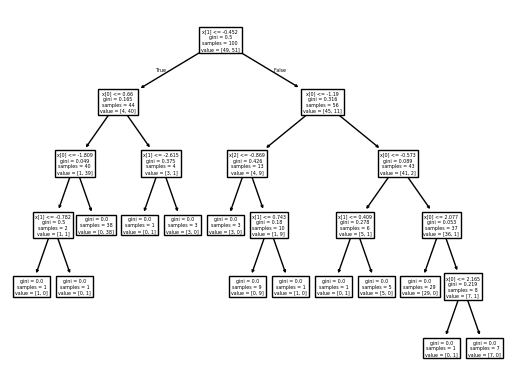

In [58]:
plot_tree(clf1)

[Text(0.3055555555555556, 0.9285714285714286, 'x[1] <= -0.452\ngini = 0.5\nsamples = 100\nvalue = [49, 51]'),
 Text(0.1111111111111111, 0.7857142857142857, 'x[0] <= -1.38\ngini = 0.165\nsamples = 44\nvalue = [4, 40]'),
 Text(0.20833333333333334, 0.8571428571428572, 'True  '),
 Text(0.05555555555555555, 0.6428571428571429, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.16666666666666666, 0.6428571428571429, 'gini = 0.0\nsamples = 40\nvalue = [0, 40]'),
 Text(0.5, 0.7857142857142857, 'x[1] <= 0.491\ngini = 0.316\nsamples = 56\nvalue = [45, 11]'),
 Text(0.4027777777777778, 0.8571428571428572, '  False'),
 Text(0.2777777777777778, 0.6428571428571429, 'x[0] <= -1.054\ngini = 0.499\nsamples = 19\nvalue = [10, 9]'),
 Text(0.16666666666666666, 0.5, 'x[1] <= 0.012\ngini = 0.198\nsamples = 9\nvalue = [8, 1]'),
 Text(0.1111111111111111, 0.35714285714285715, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.2222222222222222, 0.35714285714285715, 'x[2] <= 0.322\ngini = 0.444\nsamples = 3\nva

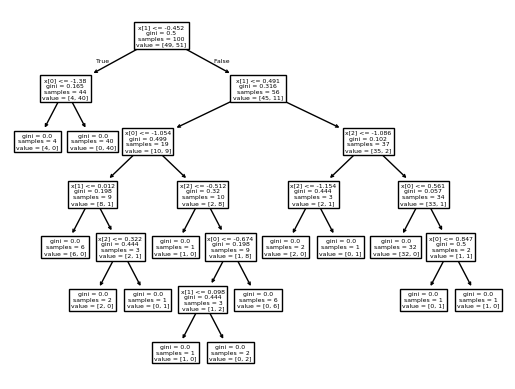

In [59]:
plot_tree(clf2)

[Text(0.4791666666666667, 0.9375, 'x[1] <= -0.452\ngini = 0.5\nsamples = 100\nvalue = [49, 51]'),
 Text(0.25, 0.8125, 'x[0] <= 0.78\ngini = 0.165\nsamples = 44\nvalue = [4, 40]'),
 Text(0.36458333333333337, 0.875, 'True  '),
 Text(0.20833333333333334, 0.6875, 'x[0] <= 0.642\ngini = 0.278\nsamples = 24\nvalue = [4, 20]'),
 Text(0.125, 0.5625, 'x[1] <= -1.713\ngini = 0.172\nsamples = 21\nvalue = [2, 19]'),
 Text(0.08333333333333333, 0.4375, 'x[1] <= -2.07\ngini = 0.408\nsamples = 7\nvalue = [2, 5]'),
 Text(0.041666666666666664, 0.3125, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.125, 0.3125, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.16666666666666666, 0.4375, 'gini = 0.0\nsamples = 14\nvalue = [0, 14]'),
 Text(0.2916666666666667, 0.5625, 'x[1] <= -1.031\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.25, 0.4375, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3333333333333333, 0.4375, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.2916666666666667, 0.6875

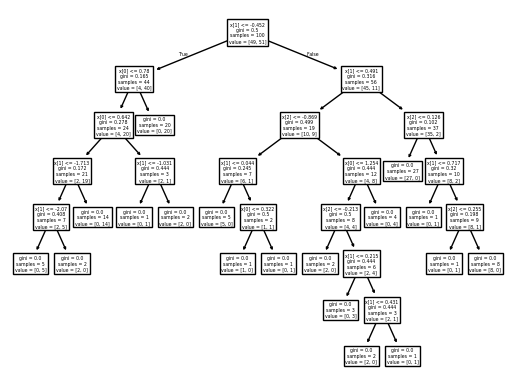

In [60]:
plot_tree(clf3)

In [61]:
print(df1.columns)

Index(['col3', 'col1', 'col5', 'col4', 'target'], dtype='object')


In [62]:
print(df2.columns)

Index(['col4', 'col1', 'col2', 'col3', 'target'], dtype='object')


In [63]:
print(df3.columns)

Index(['col2', 'col1', 'col5', 'col4', 'target'], dtype='object')


In [71]:
df3

,col2,col1,col5,col4,target
0,1.036842,-1.446423,-1.537184,0.948954,1
1,2.022841,1.290615,-2.379426,-2.491889,0
2,0.524625,-0.614230,-0.070062,0.110703,1
3,0.443148,-1.774487,-1.467568,-3.035050,0
4,0.594748,-2.807623,-3.134763,4.025850,1
...,...,...,...,...,...
95,2.011241,-0.468847,-1.692941,-0.441826,1
96,2.466238,1.801425,-3.904312,-1.056385,0
97,-0.127144,0.415524,0.645030,-2.059565,0
98,0.334771,-0.641144,1.016778,1.090157,1


In [93]:
clf1.fit(df1.iloc[:,0:4],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:4],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:4],df3.iloc[:,-1])

DecisionTreeClassifier()

In [94]:
clf1.predict(np.array([1.036842, -1.446423, -1.537184, 0.948954]).reshape(1,4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [95]:
clf2.predict(np.array([1.036842, -1.446423, -1.537184, 0.948954]).reshape(1,4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [96]:
clf3.predict(np.array([1.036842, -1.446423, -1.537184, 0.948954]).reshape(1,4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [7]:
# function for combined sampling
def combined_sampling(df,row_percent,col_percent):
  new_df=sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [102]:
dt1=combined_sampling(df,0.5,0.5)

/tmp/ipython-input-1436777600.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df["target"]=df["target"]


In [103]:
dt2=combined_sampling(df,0.5,0.5)

/tmp/ipython-input-1436777600.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df["target"]=df["target"]


In [104]:
dt3=combined_sampling(df,0.5,0.5)

/tmp/ipython-input-1436777600.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df["target"]=df["target"]


In [106]:
print(dt1.columns)
print(dt2.columns)
print(dt3.columns)


Index(['col5', 'col2', 'col4', 'target'], dtype='object')
Index(['col5', 'col1', 'col4', 'target'], dtype='object')
Index(['col4', 'col1', 'col5', 'target'], dtype='object')


In [107]:
dt3

,col4,col1,col5,target
59,-2.088702,0.537790,-1.664621,0
74,0.065916,0.066862,0.618277,1
35,2.558336,1.470058,2.383746,0
55,3.259800,-2.233684,-2.108100,1
61,0.527224,-1.375077,-2.428000,1
94,-1.372042,0.740060,-1.279059,0
2,0.110703,-0.614230,-0.070062,1
46,-1.577894,0.492377,-2.032965,0
51,-3.446267,-1.820745,-0.127536,0
79,2.620195,-0.776432,-1.150778,1


In [110]:
clf1.fit(dt1.iloc[:,0:3],dt1.iloc[:,-1])
clf2.fit(dt2.iloc[:,0:3],dt2.iloc[:,-1])
clf3.fit(dt3.iloc[:,0:3],dt3.iloc[:,-1])

DecisionTreeClassifier()

[Text(0.5, 0.9, 'x[2] <= -1.084\ngini = 0.493\nsamples = 50\nvalue = [28.0, 22.0]'),
 Text(0.3333333333333333, 0.7, 'gini = 0.0\nsamples = 22\nvalue = [22, 0]'),
 Text(0.41666666666666663, 0.8, 'True  '),
 Text(0.6666666666666666, 0.7, 'x[2] <= 0.836\ngini = 0.337\nsamples = 28\nvalue = [6, 22]'),
 Text(0.5833333333333333, 0.8, '  False'),
 Text(0.5, 0.5, 'x[1] <= 0.835\ngini = 0.48\nsamples = 15\nvalue = [6, 9]'),
 Text(0.3333333333333333, 0.3, 'x[0] <= 0.532\ngini = 0.245\nsamples = 7\nvalue = [6, 1]'),
 Text(0.16666666666666666, 0.1, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.5, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6666666666666666, 0.3, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.8333333333333334, 0.5, 'gini = 0.0\nsamples = 13\nvalue = [0, 13]')]

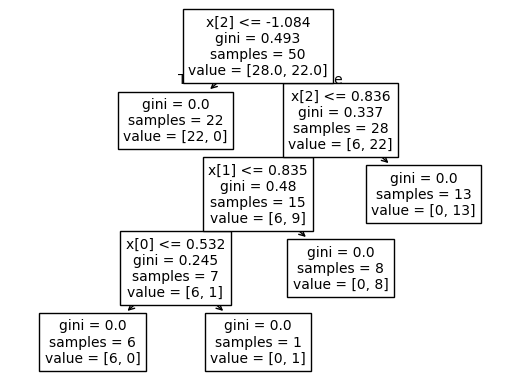

In [111]:
plot_tree(clf1)

[Text(0.5, 0.9, 'x[1] <= 0.491\ngini = 0.493\nsamples = 50\nvalue = [28.0, 22.0]'),
 Text(0.3, 0.7, 'x[2] <= -0.674\ngini = 0.33\nsamples = 24\nvalue = [5, 19]'),
 Text(0.4, 0.8, 'True  '),
 Text(0.2, 0.5, 'x[1] <= 0.098\ngini = 0.278\nsamples = 6\nvalue = [5, 1]'),
 Text(0.1, 0.3, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.3, 0.3, 'x[0] <= -0.089\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.2, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4, 0.5, 'gini = 0.0\nsamples = 18\nvalue = [0, 18]'),
 Text(0.7, 0.7, 'x[2] <= 0.561\ngini = 0.204\nsamples = 26\nvalue = [23, 3]'),
 Text(0.6, 0.8, '  False'),
 Text(0.6, 0.5, 'gini = 0.0\nsamples = 20\nvalue = [20, 0]'),
 Text(0.8, 0.5, 'x[2] <= 0.681\ngini = 0.5\nsamples = 6\nvalue = [3, 3]'),
 Text(0.7, 0.3, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.9, 0.3, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]')]

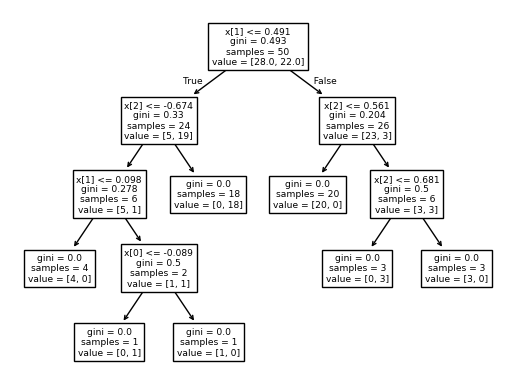

In [112]:
plot_tree(clf2)

[Text(0.5, 0.9, 'x[0] <= -1.084\ngini = 0.487\nsamples = 50\nvalue = [21.0, 29.0]'),
 Text(0.2, 0.7, 'x[2] <= -1.112\ngini = 0.188\nsamples = 19\nvalue = [17, 2]'),
 Text(0.35, 0.8, 'True  '),
 Text(0.1, 0.5, 'gini = 0.0\nsamples = 12\nvalue = [12, 0]'),
 Text(0.3, 0.5, 'x[2] <= -0.711\ngini = 0.408\nsamples = 7\nvalue = [5, 2]'),
 Text(0.2, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.4, 0.3, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.8, 0.7, 'x[1] <= 0.826\ngini = 0.225\nsamples = 31\nvalue = [4, 27]'),
 Text(0.65, 0.8, '  False'),
 Text(0.7, 0.5, 'x[0] <= -0.449\ngini = 0.069\nsamples = 28\nvalue = [1, 27]'),
 Text(0.6, 0.3, 'x[1] <= 0.098\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.5, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.7, 0.1, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.8, 0.3, 'gini = 0.0\nsamples = 23\nvalue = [0, 23]'),
 Text(0.9, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]')]

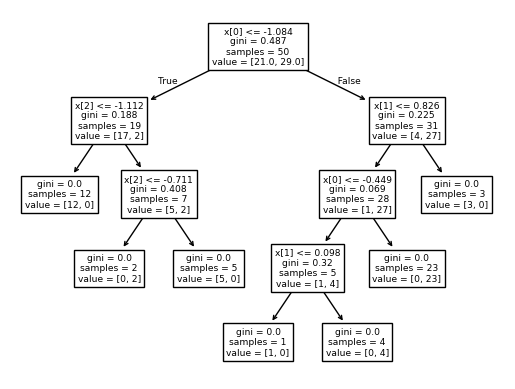

In [113]:
plot_tree(clf3)

In [114]:
dt3

,col4,col1,col5,target
59,-2.088702,0.537790,-1.664621,0
74,0.065916,0.066862,0.618277,1
35,2.558336,1.470058,2.383746,0
55,3.259800,-2.233684,-2.108100,1
61,0.527224,-1.375077,-2.428000,1
94,-1.372042,0.740060,-1.279059,0
2,0.110703,-0.614230,-0.070062,1
46,-1.577894,0.492377,-2.032965,0
51,-3.446267,-1.820745,-0.127536,0
79,2.620195,-0.776432,-1.150778,1


In [119]:
clf1.predict(np.array([0.065916,	0.066862,	0.618277]).reshape(1,3))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [117]:
clf2.predict(np.array([0.065916,	0.066862,	0.618277]).reshape(1,3))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [118]:
clf3.predict(np.array([0.065916,	0.066862,	0.618277]).reshape(1,3))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])